# **Colab setup**

In [1]:
# Basic installs (only if needed)
!pip install numpy==1.23.5
!pip install gensim
!pip install gradio

# Imports
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import nltk
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import gensim.downloader as api

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import gradio as gr

print(tf.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 39.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 71.5 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


2.20.0


# **1. Load and inspect dataset**

In [6]:
from google.colab import drive
drive.mount('/content/drive')

# 1. Load data from Drive
path = "/content/drive/MyDrive/AI and Machine Learning/spamvsham.csv"
df = pd.read_csv(path, encoding="latin-1")

df = df.rename(columns={'v1': 'label', 'v2': 'text'})
df = df[['label', 'text']]
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
# 1.2 Basic info and class distribution
df.info()
df['label'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   5572 non-null   object
 1   text    5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


,count
label,
ham,4825
spam,747


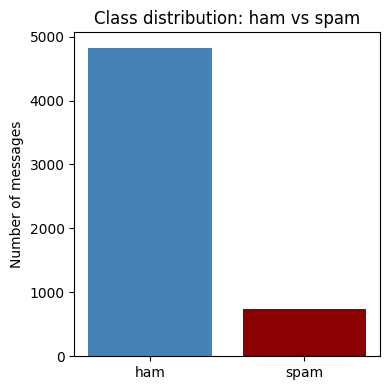

In [34]:
import matplotlib.pyplot as plt

label_counts = df['label'].value_counts().sort_index()   # ham, spam

plt.figure(figsize=(4,4))
plt.bar(label_counts.index, label_counts.values, color=['steelblue', 'darkred'])
plt.ylabel("Number of messages")
plt.title("Class distribution: ham vs spam")
plt.tight_layout()
plt.show()

In [8]:
# 1.3 Map labels to numeric (ham=0, spam=1)
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})
df[['label', 'label_num']].head()

,label,label_num
0,ham,0
1,ham,0
2,spam,1
3,ham,0
4,ham,0


# **2. Text preprocessing**

## **2.1 Define cleaning function**

In [10]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # convert to string and lower-case
    text = str(text).lower()
    # remove URLs
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    # remove @mentions and hashtags
    text = re.sub(r'@[A-Za-z0-9_]+', ' ', text)
    text = re.sub(r'#[A-Za-z0-9_]+', ' ', text)
    # handle a few common contractions
    text = text.replace("can't", "can not").replace("won't", "will not")
    text = text.replace("n't", " not").replace("'re", " are")
    text = text.replace("'s", " is").replace("'ll", " will")
    # keep only letters and spaces
    text = re.sub(r'[^a-z\s]', ' ', text)
    # tokenise
    tokens = text.split()
    # remove stopwords and lemmatise
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return " ".join(tokens)

## **2.2 Apply cleaning and quick check**

In [11]:
df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text']].head()

,text,clean_text
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah think go usf life around though


## **2.3 Simple length distribution plot**

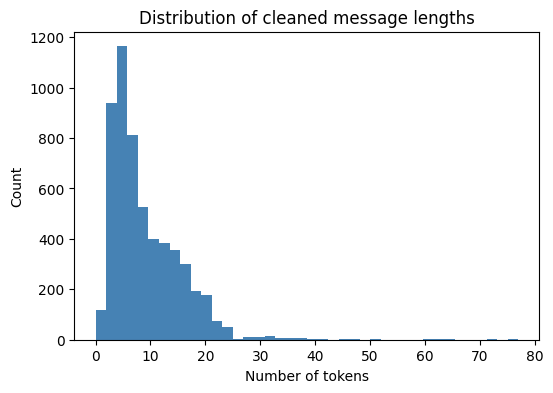

In [12]:
lengths = df['clean_text'].apply(lambda x: len(x.split()))
plt.figure(figsize=(6,4))
plt.hist(lengths, bins=40, color='steelblue')
plt.xlabel('Number of tokens')
plt.ylabel('Count')
plt.title('Distribution of cleaned message lengths')
plt.show()

## **2.4 Most frequent words (overall, ham, spam)**

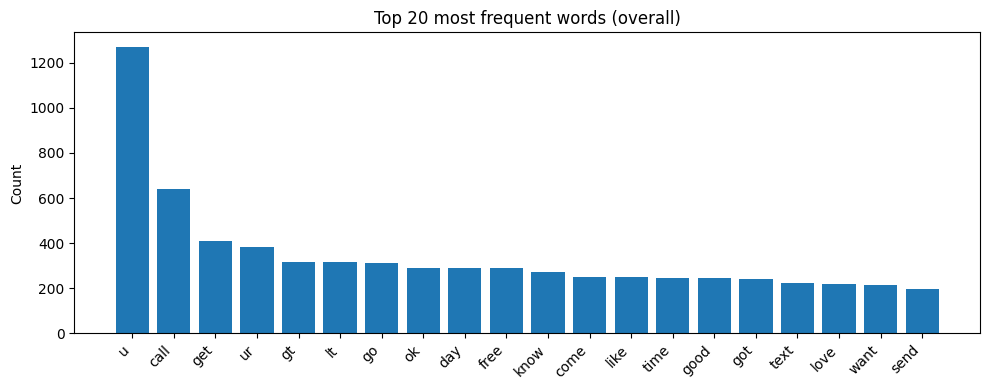

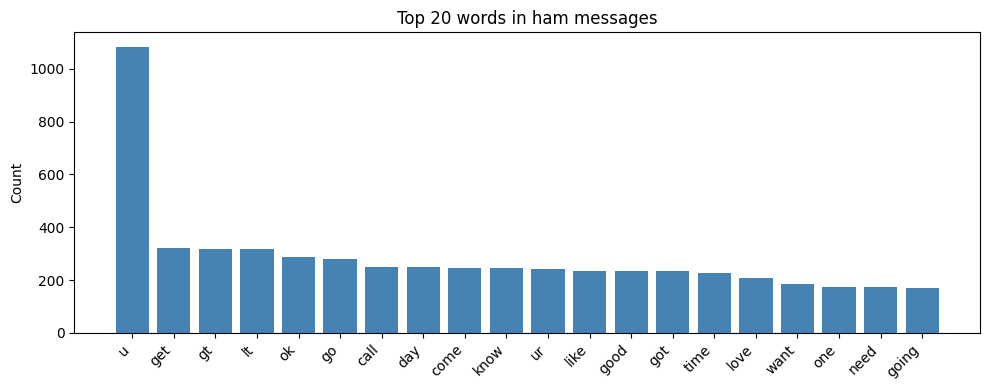

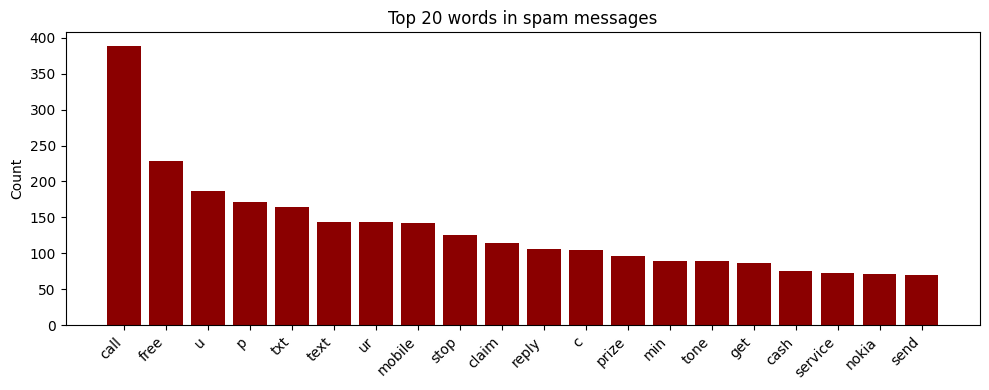

In [33]:
from collections import Counter
import matplotlib.pyplot as plt

def top_words(text_series, n=20):
    all_tokens = " ".join(text_series).split()
    counter = Counter(all_tokens)
    return counter.most_common(n)

# overall
top_overall = top_words(df['clean_text'], n=20)
words_o, counts_o = zip(*top_overall)

plt.figure(figsize=(10,4))
plt.bar(words_o, counts_o)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Count")
plt.title("Top 20 most frequent words (overall)")
plt.tight_layout()
plt.show()

# ham
top_ham = top_words(df[df['label']=='ham']['clean_text'], n=20)
words_h, counts_h = zip(*top_ham)

plt.figure(figsize=(10,4))
plt.bar(words_h, counts_h, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Count")
plt.title("Top 20 words in ham messages")
plt.tight_layout()
plt.show()

# spam
top_spam = top_words(df[df['label']=='spam']['clean_text'], n=20)
words_s, counts_s = zip(*top_spam)

plt.figure(figsize=(10,4))
plt.bar(words_s, counts_s, color='darkred')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Count")
plt.title("Top 20 words in spam messages")
plt.tight_layout()
plt.show()

# **3. Train–test split, tokenisation, and padding**

## **3.1 Train–test split**

In [13]:
X = df['clean_text'].values
y = df['label_num'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

len(X_train), len(X_test)

(4457, 1115)

## **3.2 Tokeniser and sequences**

In [14]:
max_words = 10000  # maximum vocabulary size

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

train_seqs = tokenizer.texts_to_sequences(X_train)
test_seqs = tokenizer.texts_to_sequences(X_test)

# compute 95th percentile length
seq_lengths = [len(s) for s in train_seqs]
max_len = int(np.percentile(seq_lengths, 95))
max_len

20

## **3.3 Apply padding**

In [15]:
X_train_pad = pad_sequences(train_seqs, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(test_seqs, maxlen=max_len, padding='post', truncating='post')

vocab_size = min(max_words, len(tokenizer.word_index) + 1)
vocab_size, max_len

(6230, 20)

# **4. Helper functions**

In [16]:
def plot_history(history, title):
    plt.figure(figsize=(12,4))

    # accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='train')
    plt.plot(history.history['val_accuracy'], label='val')
    plt.title(title + ' - accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='val')
    plt.title(title + ' - loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()


def evaluate_model(model, X_test, y_test, title):
    y_prob = model.predict(X_test)
    y_pred = (y_prob > 0.5).astype(int)

    print(f"{title} - classification report:")
    print(classification_report(y_test, y_pred, target_names=['ham','spam']))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['ham','spam'],
                yticklabels=['ham','spam'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(title + ' - confusion matrix')
    plt.show()

    return y_prob, y_pred

In [17]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
embedding_dim = 50

# **5. Model 1 – Simple RNN with trainable Embedding**
## **5.1 Build model**

In [18]:
model_rnn = Sequential()
model_rnn.add(Embedding(input_dim=vocab_size,
                        output_dim=embedding_dim,
                        input_length=max_len))
model_rnn.add(SimpleRNN(64))
model_rnn.add(Dropout(0.5))
model_rnn.add(Dense(1, activation='sigmoid'))

model_rnn.compile(loss='binary_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

model_rnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## **5.2 Train model**

Epoch 1/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9966 - loss: 0.0179 - val_accuracy: 0.9496 - val_loss: 0.1518
Epoch 2/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9966 - loss: 0.0120 - val_accuracy: 0.9686 - val_loss: 0.1179
Epoch 3/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9980 - loss: 0.0077 - val_accuracy: 0.9585 - val_loss: 0.1354


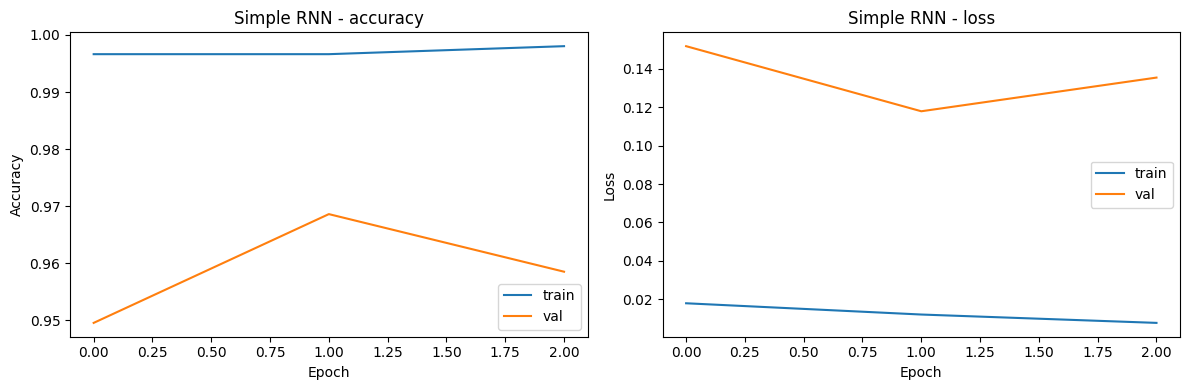

In [36]:
history_rnn = model_rnn.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

plot_history(history_rnn, "Simple RNN")

## **5.3 Evaluate model**

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Simple RNN - classification report:
              precision    recall  f1-score   support

         ham       0.98      0.99      0.98       966
        spam       0.94      0.84      0.89       149

    accuracy                           0.97      1115
   macro avg       0.96      0.92      0.94      1115
weighted avg       0.97      0.97      0.97      1115



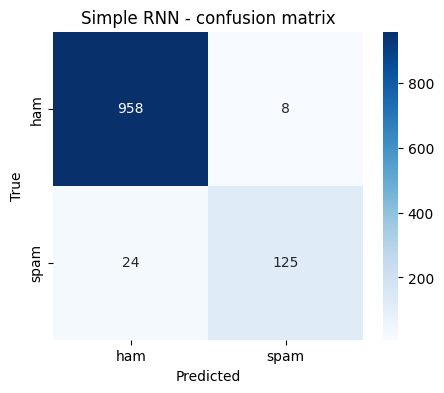

In [20]:
rnn_prob, rnn_pred = evaluate_model(model_rnn, X_test_pad, y_test, "Simple RNN")

# **6. Model 2 – LSTM with trainable Embedding**

## **6.1 Build model**

In [21]:
model_lstm = Sequential()
model_lstm.add(Embedding(input_dim=vocab_size,
                         output_dim=embedding_dim,
                         input_length=max_len))
model_lstm.add(LSTM(64))
model_lstm.add(Dropout(0.5))
model_lstm.add(Dense(1, activation='sigmoid'))

model_lstm.compile(loss='binary_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

model_lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## **6.2 Train and evaluate**

Epoch 1/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.8805 - loss: 0.3160 - val_accuracy: 0.9675 - val_loss: 0.1282
Epoch 2/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9804 - loss: 0.0744 - val_accuracy: 0.9742 - val_loss: 0.0823
Epoch 3/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9930 - loss: 0.0285 - val_accuracy: 0.9765 - val_loss: 0.0713
Epoch 4/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9975 - loss: 0.0098 - val_accuracy: 0.9787 - val_loss: 0.1008
Epoch 5/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9992 - loss: 0.0029 - val_accuracy: 0.9742 - val_loss: 0.1269
Epoch 6/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9992 - loss: 0.0025 - val_accuracy: 0.9742 - val_loss: 0.1368


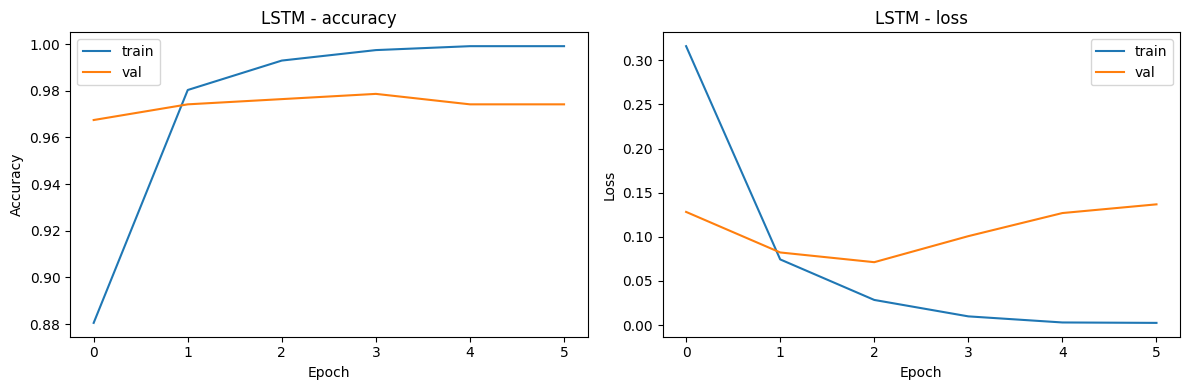

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
LSTM - classification report:
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       966
        spam       0.99      0.92      0.95       149

    accuracy                           0.99      1115
   macro avg       0.99      0.96      0.97      1115
weighted avg       0.99      0.99      0.99      1115



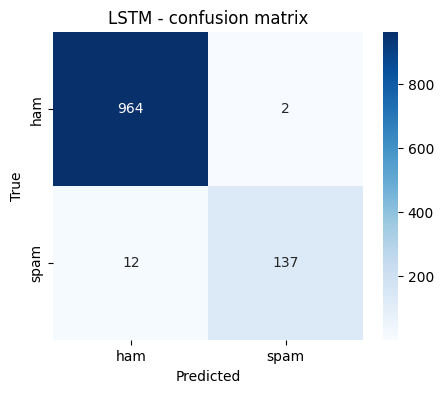

In [22]:
history_lstm = model_lstm.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

plot_history(history_lstm, "LSTM")

lstm_prob, lstm_pred = evaluate_model(model_lstm, X_test_pad, y_test, "LSTM")

# **7. Model 3 – LSTM with pretrained GloVe (Word2Vec‑style)**
## **7.1 Load pretrained embeddings**

In [23]:
embedding_model = api.load('glove-wiki-gigaword-50')  # 50‑dim embeddings
embedding_dim = 50

[==================================================] 100.0% 66.0/66.0MB downloaded


## **7.2 Build embedding matrix**

In [24]:
word_index = tokenizer.word_index
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in word_index.items():
    if i >= vocab_size:
        continue
    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]

## **7.3 Build and train model**

In [25]:
model_lstm_w2v = Sequential()
model_lstm_w2v.add(Embedding(input_dim=vocab_size,
                             output_dim=embedding_dim,
                             weights=[embedding_matrix],
                             input_length=max_len,
                             trainable=False))
model_lstm_w2v.add(LSTM(64))
model_lstm_w2v.add(Dropout(0.5))
model_lstm_w2v.add(Dense(1, activation='sigmoid'))

model_lstm_w2v.compile(loss='binary_crossentropy',
                       optimizer='adam',
                       metrics=['accuracy'])

model_lstm_w2v.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │       311,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 311,500 (1.19 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 311,500 (1.19 MB)

Epoch 1/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9010 - loss: 0.3157 - val_accuracy: 0.9496 - val_loss: 0.1438
Epoch 2/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9641 - loss: 0.1090 - val_accuracy: 0.9596 - val_loss: 0.1094
Epoch 3/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9714 - loss: 0.0998 - val_accuracy: 0.9641 - val_loss: 0.1028


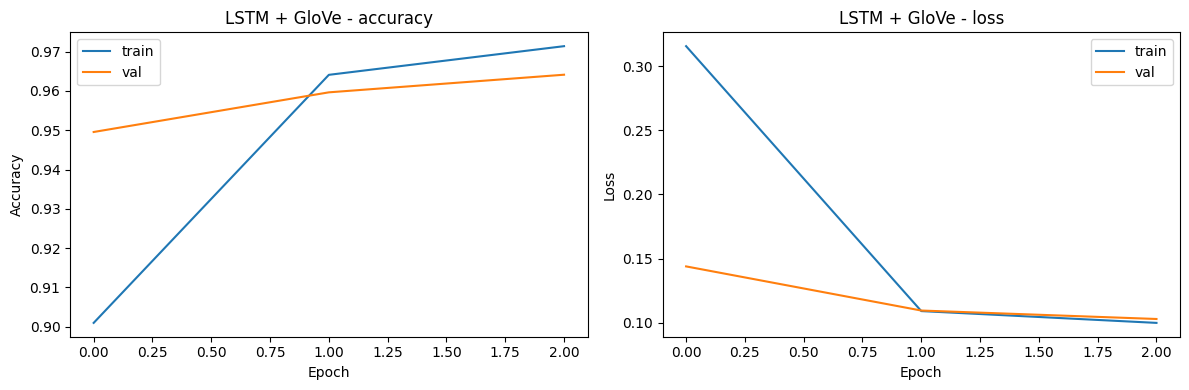

In [26]:
history_lstm_w2v = model_lstm_w2v.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

plot_history(history_lstm_w2v, "LSTM + GloVe")

## **7.4 Evaluate model**

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
LSTM + GloVe - classification report:
              precision    recall  f1-score   support

         ham       0.96      0.98      0.97       966
        spam       0.85      0.74      0.79       149

    accuracy                           0.95      1115
   macro avg       0.90      0.86      0.88      1115
weighted avg       0.95      0.95      0.95      1115



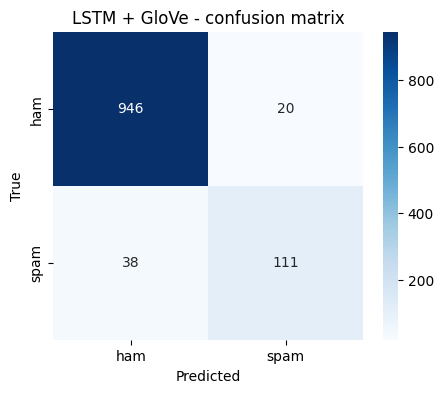

In [27]:
w2v_prob, w2v_pred = evaluate_model(model_lstm_w2v, X_test_pad, y_test, "LSTM + GloVe")

# **8. Error analysis**

In [28]:
# Choose the best model for error analysis; suppose LSTM+GloVe
y_pred_best = w2v_pred.reshape(-1)

mis_idx = np.where(y_test != y_pred_best)[0]
len(mis_idx)

58

In [29]:
# Show 3 misclassified messages
for i in mis_idx[:3]:
    print("TEXT:", X_test[i])
    print("TRUE LABEL:", y_test[i], "(0=ham, 1=spam)")
    print("PREDICTED:", int(y_pred_best[i]))
    print("-"*80)

TEXT: cash prize claim call
TRUE LABEL: 1 (0=ham, 1=spam)
PREDICTED: 0
--------------------------------------------------------------------------------
TEXT: unsubscribed service get ton sexy babe hunk straight phone go subscription
TRUE LABEL: 1 (0=ham, 1=spam)
PREDICTED: 0
--------------------------------------------------------------------------------
TEXT: send content page
TRUE LABEL: 0 (0=ham, 1=spam)
PREDICTED: 1
--------------------------------------------------------------------------------


# **9. Simple GUI for real‑time prediction**

In [30]:
label_map = {0: "Ham (not spam)", 1: "Spam"}

def predict_sms(text):
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    pad = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')
    prob = model_lstm_w2v.predict(pad)[0][0]
    pred = int(prob > 0.5)
    return f"{label_map[pred]} (probability = {prob:.3f})"

iface = gr.Interface(
    fn=predict_sms,
    inputs="text",
    outputs="text",
    title="SMS Spam Detector",
    description="Type an SMS message to see if it is spam or not."
)

iface.launch(share=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

# **10. Final comparison table**

In [31]:
results = []

from sklearn.metrics import accuracy_score, f1_score

def add_result(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    results.append({"Model": name,
                    "Test accuracy": acc,
                    "Test F1": f1})

add_result("Simple RNN", y_test, rnn_pred)
add_result("LSTM", y_test, lstm_pred)
add_result("LSTM + GloVe", y_test, w2v_pred)

df_results = pd.DataFrame(results)
df_results

,Model,Test accuracy,Test F1
0,Simple RNN,0.971300,0.886525
1,LSTM,0.987444,0.951389
2,LSTM + GloVe,0.947982,0.792857


In [32]:
df_results.to_csv("model_comparison_spamvsham.csv", index=False)